# Notebook 04 — PD Model: Logistic Regression

This notebook builds the **Probability of Default (PD) model** using logistic regression
on the WoE-binned features prepared in Notebook 03.

**Input files** (from `../data/processed/`):
- `loan_data_inputs_train.csv`
- `loan_data_targets_train.csv`
- `loan_data_inputs_test.csv`
- `loan_data_targets_test.csv`

**Output files** (saved to `../data/processed/`):
- `pd_model.pkl` — fitted model object
- `pd_model_features.csv` — list of features used in the final model

**Steps**:
1. Load data
2. Drop reference categories to avoid the dummy variable trap
3. Fit logistic regression using statsmodels
4. Review coefficients and p-values
5. Remove statistically insignificant variables and refit
6. Validate on test set — AUC, Gini, KS
7. Save the model

## 2. Drop Reference Categories — Avoiding the Dummy Variable Trap

### Why this is necessary

In Notebook 03, every continuous variable was split into bins and each bin
became a dummy variable (0 or 1). Because every observation belongs to
exactly one bin, the bins for any single variable always sum to 1:

```
bin_1 + bin_2 + bin_3 + ... + bin_N = 1  for every row
```

This means the bins are perfectly collinear — one bin can always be
reconstructed from the others. Including all of them in a regression makes
the model matrix singular and the coefficients cannot be estimated.
This is known as the **dummy variable trap**.

The solution is to drop one bin per variable before fitting the model.
The dropped bin becomes the **reference category** and its effect is absorbed
into the model intercept. All remaining coefficients are then interpreted
*relative to the reference group*.

### Which bin to drop?

We drop the **lowest-risk bin** for each variable.

The lowest-risk bin is the one with:

* The **highest (most positive) WoE** — because WoE = ln(prop_good / prop_bad),
  so a high WoE indicates a larger proportion of non-defaulters
* The **lowest observed default rate**, consistent with the WoE sign

By dropping the safest bin, every remaining coefficient answers the question:

> *"How much riskier is this borrower group compared to the safest borrowers?"*

In practice, this typically results in **positive coefficients** for higher-risk bins,
making the model easier to interpret.

### Important note

The choice of reference category has **no effect on model predictions,
AUC, Gini, or KS statistic**. It only affects how the coefficients are interpreted.
Dropping a different bin would produce identical predicted probabilities,
but the coefficients would be expressed relative to a different baseline group.

### Reference categories chosen

| Variable                      | Reference bin dropped              | Reasoning                                                      |
| ----------------------------- | ---------------------------------- | -------------------------------------------------------------- |
| `int_rate`                    | `int_rate:<9.548`                  | Lowest interest rate = lowest borrower risk                    |
| `dti`                         | `dti:<=1.4`                        | Lowest debt burden relative to income                          |
| `revol_util`                  | `revol_util:<29.0`                 | Lowest credit utilization                                      |
| `annual_inc`                  | `annual_inc:>140K`                 | Highest income = strongest repayment capacity                  |
| `funded_amnt`                 | Highest WoE bin                    | Determined from WoE diagnostics                                |
| `installment`                 | Highest WoE bin                    | Determined from WoE diagnostics                                |
| `inq_last_6mths`              | `inq_last_6mths:0`                 | No recent credit inquiries                                     |
| `months_since_issue_date`     | `months_since_issue_date:>84`      | Most seasoned loans                                            |
| `mths_since_earliest_cr_line` | `mths_since_earliest_cr_line:>352` | Longest credit history                                         |
| `sub_grade`                   | `sub_grade:A1`                     | Best LendingClub grade                                         |
| `purpose`                     | `purpose:low_risk`                 | Lowest default rate group                                      |
| `home_ownership`              | `home_ownership:RENT_ANY`          | Lowest observed default rate                                   |
| `addr_state`                  | `addr_state:low_risk`              | Lowest risk state group                                        |
| `verification_status`         | `verification_status:Not_Verified` | Lowest observed default rate                                   |
| `term_month:60`               | none                               | 36-month loans are implicitly the reference when this equals 0 |

### Note on verification_status

It may seem counterintuitive that **"Not Verified"** appears as the safest
group. This pattern is frequently observed in retail lending datasets.

Income verification is often requested when the lender already has concerns
about a borrower's credit profile. As a result, the verified population can
contain a higher concentration of risky borrowers. The model therefore
captures a **selection effect** rather than a data error.


## 1. Imports

In [1]:
import numpy as np                        # numerical operations
import pandas as pd                       # dataframes
import statsmodels.api as sm              # logistic regression with p-values built in
import matplotlib.pyplot as plt           # plotting
from sklearn.metrics import roc_curve, roc_auc_score  # model evaluation
%matplotlib inline

## 2. Load Data

We load the four files saved at the end of Notebook 03.

- `X_train` / `X_test`  — WoE-binned dummy features
- `y_train` / `y_test`  — the target: 1 = defaulted, 0 = did not default

The index column (row 0 of the CSV) is the original loan index from the
raw dataset. We restore it here with `index_col=0` so rows stay aligned
across all four files.

In [2]:
# Load training features — WoE dummy variables from Notebook 03
X_train = pd.read_csv('../data/processed/loan_data_inputs_train.csv', index_col=0)

# Load test features
X_test  = pd.read_csv('../data/processed/loan_data_inputs_test.csv',  index_col=0)

# Load training labels
# The targets CSV was saved with y_train.to_csv() in Notebook 03
# which writes: index, value — two columns, no header
# index_col=0 takes the first column as the index
# squeeze() converts the remaining single column into a Series
# astype(int) forces the values to integer in case they loaded as strings
y_train = pd.read_csv('../data/processed/loan_data_targets_train.csv',
                      index_col=0).iloc[:,0].astype(int)

y_test = pd.read_csv('../data/processed/loan_data_targets_test.csv',
                     index_col=0).iloc[:,0].astype(int)

# Confirm shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

# Confirm dtype is now integer
print("\ny_train dtype:", y_train.dtype)
print("y_test  dtype:", y_test.dtype)

# Sanity check — default rate should be ~19%
print(f"\nDefault rate — train: {y_train.mean():.4f}")
print(f"Default rate — test:  {y_test.mean():.4f}")

X_train: (184636, 166)
y_train: (184636,)
X_test:  (46159, 166)
y_test:  (46159,)

y_train dtype: int32
y_test  dtype: int32

Default rate — train: 0.1909
Default rate — test:  0.1909


In [3]:
# Reload the originals cleanly since we overwrote them above
X_train = pd.read_csv('../data/processed/loan_data_inputs_train.csv', index_col=0)
X_test  = pd.read_csv('../data/processed/loan_data_inputs_test.csv',  index_col=0)

# Reference bins — safest bin per variable (12 confirmed working)
reference_bins = [
    'int_rate:<9.548',
    'dti:<=1.4',
    'revol_util:<29.0',
    'annual_inc:>140K',
    'inq_last_6mths:0',
    'months_since_issue_date:>84',
    'mths_since_earliest_cr_line:>352',
    'sub_grade:A1',
    'purpose:low_risk',
    'home_ownership:RENT_ANY',
    'addr_state:low_risk',
    'verification_status:Not_Verified',
]

# Drop into new variables — originals stay untouched
X_train_model = X_train.drop(columns=reference_bins, errors='ignore')
X_test_model  = X_test.drop(columns=reference_bins,  errors='ignore')

print("X_train preserved:       ", X_train.shape)
print("X_train_model (for fit): ", X_train_model.shape)
print("X_test_model  (for fit): ", X_test_model.shape)

X_train preserved:        (184636, 166)
X_train_model (for fit):  (184636, 154)
X_test_model  (for fit):  (46159, 154)


## 4. Fit Logistic Regression

We estimate the **Probability of Default (PD)** model using **two libraries in parallel**.

| Library       | Why we use it                                                                                                                                                                   |
| ------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `statsmodels` | Provides full statistical output: coefficients, standard errors, p-values, and confidence intervals. This allows us to evaluate which predictors are statistically significant. |
| `sklearn`     | Provides fast model fitting and convenient prediction tools for computing metrics such as AUC.                                                                                  |

Both libraries fit the **same logistic regression model on the same dataset**.
If their predicted probabilities are consistent, this confirms that the model implementation is correct.

---

### What the model is doing

Logistic regression models the **log-odds of default** as a linear function of the predictors:

[
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ...
]

Where:

* (p) = probability of default
* (X_i) = predictor variables (WoE bin dummy variables)
* (\beta_i) = model coefficients

The model estimates the values of the coefficients ( \beta ) that make the **observed defaults most likely** under this equation.
This estimation method is called **Maximum Likelihood Estimation (MLE)**.

During estimation, the solver repeatedly adjusts the coefficients until the improvement in likelihood becomes negligible. When this happens, the algorithm is said to have **converged**.

---

### Why we add a constant manually for `statsmodels`

Unlike `sklearn`, **statsmodels does not automatically include an intercept** in the model.

Therefore we manually add a constant column using:

```python
sm.add_constant()
```

This column contains ones and represents the **intercept term ( \beta_0 )**.

The intercept corresponds to the **baseline log-odds of default** when a borrower belongs to **all reference categories simultaneously**.

In contrast, `sklearn` automatically includes the intercept int


In [4]:
# ---------------------------------------------------------------
# Logistic Regression using statsmodels (for statistical output)
# ---------------------------------------------------------------

import statsmodels.api as sm

# Add constant (intercept)
# statsmodels does NOT automatically add an intercept
X_train_sm = sm.add_constant(X_train_model)

# Convert all columns to numeric (required for statsmodels)
X_train_sm = X_train_sm.astype(float)

# Build logistic regression model
logit_model = sm.Logit(y_train, X_train_sm)

# Fit model using Maximum Likelihood Estimation
result = logit_model.fit()

# Print model summary
print(result.summary())

         Current function value: 0.443292
         Iterations: 35


C:\Users\amit_\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:               184636
Model:                          Logit   Df Residuals:                   184487
Method:                           MLE   Df Model:                          148
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                 0.09083
Time:                        12:34:48   Log-Likelihood:                -81848.
converged:                      False   LL-Null:                       -90025.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                 -59.2810        nan        nan        nan         nan         nan
total_acc                              -0.0044      0.00

## 5. Diagnosing and Fixing Collinearity Issues

After reviewing the first model output, we identified three problems
that need to be fixed before the model is reliable.

---

### Problem 1 — Individual state dummies AND grouped state dummies both present

In Notebook 03 we did two things with `addr_state`:

1. Created **50 individual state dummies** using `pd.get_dummies()`
   e.g. `addr_state_CA`, `addr_state_NY`, `addr_state_TX` ...

2. Then grouped those states into **4 risk buckets**:
   `addr_state:very_risky`, `addr_state:below_avg`,
   `addr_state:average`, `addr_state:low_risk`

The problem is **both sets are still in the data**.
A borrower from California has `addr_state_CA = 1` AND
`addr_state:average = 1` at the same time.
These two columns carry the same information — perfect collinearity.

statsmodels cannot compute standard errors when columns are perfectly
collinear, which is why those rows show `NaN` for p-values.

**Fix**: drop all 50 individual state dummies. Keep only the 4 grouped
risk buckets — that is the version we designed in Notebook 03.

---

### Problem 2 — `funded_amnt` and `installment` bins still present

We flagged these two variables in the WoE analysis as:
- Non-monotonic (WoE does not move cleanly in one direction)
- Highly correlated with each other (larger loans = larger installments)
- Showing `NaN` standard errors in the model output

**Fix**: drop all `funded_amnt` and `installment` bins entirely.
The model will rely on `int_rate`, `annual_inc`, and `dti` to capture
loan size and repayment burden, which do this more cleanly.

---

### Problem 3 — `addr_state_ME` coefficient of -37

Maine (ME) has near-zero defaults in the training data.
When a group has almost no events, logistic regression pushes the
coefficient toward negative infinity trying to fit a probability of
nearly zero. This is called **quasi-complete separation**.

This is another reason to drop the individual state dummies entirely
and use only the grouped risk buckets — small states get absorbed into
a group with stable counts.

---

### Problem 4 — `const` has a standard error of 609,000

This is a direct symptom of the collinearity above.
When redundant columns are present, the model cannot pin down the
intercept value — it could be shifted by any amount and compensated
by the redundant columns. Once we fix the collinearity, the intercept
standard error will return to a normal range.

---

### What we fix in the next cell

1. Drop all 50 individual `addr_state_XX` dummy columns
2. Drop all `funded_amnt` bins
3. Drop all `installment` bins
4. Refit the model on the cleaned feature set

In [5]:
# ── DIAGNOSE THE COLLINEARITY PROBLEM ────────────────────────────
# Check which addr_state columns exist in X_train_model

# ── CHECK STATE VARIABLES ─────────────────────────────

# Find columns that represent individual states
state_cols = [c for c in X_train_model.columns if "addr_state_" in c]

# Find columns that represent grouped state risk buckets
state_groups = [c for c in X_train_model.columns if "addr_state:" in c]

print("Number of individual state columns:", len(state_cols))
print(state_cols)

print("\nNumber of grouped state columns:", len(state_groups))
print(state_groups)


# ── CHECK LOAN SIZE VARIABLES ─────────────────────────

# funded_amnt bins
fund_cols = [c for c in X_train_model.columns if "funded_amnt" in c]

# installment bins
inst_cols = [c for c in X_train_model.columns if "installment" in c]

print("\nfunded_amnt columns:")
print(fund_cols)

print("\ninstallment columns:")
print(inst_cols)

Number of individual state columns: 50
['addr_state_AK', 'addr_state_AL', 'addr_state_AR', 'addr_state_AZ', 'addr_state_CA', 'addr_state_CO', 'addr_state_CT', 'addr_state_DC', 'addr_state_DE', 'addr_state_FL', 'addr_state_GA', 'addr_state_HI', 'addr_state_IA', 'addr_state_ID', 'addr_state_IL', 'addr_state_IN', 'addr_state_KS', 'addr_state_KY', 'addr_state_LA', 'addr_state_MA', 'addr_state_MD', 'addr_state_ME', 'addr_state_MI', 'addr_state_MN', 'addr_state_MO', 'addr_state_MS', 'addr_state_MT', 'addr_state_NC', 'addr_state_NE', 'addr_state_NH', 'addr_state_NJ', 'addr_state_NM', 'addr_state_NV', 'addr_state_NY', 'addr_state_OH', 'addr_state_OK', 'addr_state_OR', 'addr_state_PA', 'addr_state_RI', 'addr_state_SC', 'addr_state_SD', 'addr_state_TN', 'addr_state_TX', 'addr_state_UT', 'addr_state_VA', 'addr_state_VT', 'addr_state_WA', 'addr_state_WI', 'addr_state_WV', 'addr_state_WY']

Number of grouped state columns: 3
['addr_state:very_risky', 'addr_state:below_avg', 'addr_state:average']

f

In [6]:
# ── STEP 1: IDENTIFY COLUMNS TO REMOVE ─────────────────────────

# Individual state dummies (50 columns)
state_cols = [c for c in X_train_model.columns if c.startswith("addr_state_")]

# funded_amnt bins
fund_cols = [c for c in X_train_model.columns if c.startswith("funded_amnt")]

# installment bins
inst_cols = [c for c in X_train_model.columns if c.startswith("installment")]

# Combine and remove duplicates
cols_to_drop = list(set(state_cols + fund_cols + inst_cols))

print("State columns:", len(state_cols))
print("funded_amnt columns:", len(fund_cols))
print("installment columns:", len(inst_cols))
print("Total columns to drop:", len(cols_to_drop))


# ── STEP 2: DROP FROM TRAIN AND TEST ───────────────────────────

X_train_v2 = X_train_model.drop(columns=cols_to_drop)
X_test_v2  = X_test_model.drop(columns=cols_to_drop)

print("\nColumns before:", X_train_model.shape[1])
print("Columns after :", X_train_v2.shape[1])


# ── STEP 3: ADD CONSTANT FOR STATSMODELS ───────────────────────

X_train_v2_sm = sm.add_constant(X_train_v2)
X_test_v2_sm  = sm.add_constant(X_test_v2)

# Ensure numeric types
X_train_v2_sm = X_train_v2_sm.astype(float)
X_test_v2_sm  = X_test_v2_sm.astype(float)


# ── STEP 4: REFIT MODEL ───────────────────────────────────────

model_v2 = sm.Logit(y_train, X_train_v2_sm)

result_v2 = model_v2.fit(maxiter=300, disp=False)


# ── STEP 5: CHECK MODEL FIT ───────────────────────────────────

print("\nModel convergence:", result_v2.mle_retvals['converged'])
print("Log-likelihood:", round(result_v2.llf, 2))
print("Pseudo R²:", round(result_v2.prsquared, 4))
print("Number of features:", X_train_v2.shape[1])

State columns: 50
funded_amnt columns: 6
installment columns: 5
Total columns to drop: 61

Columns before: 154
Columns after : 93

Model convergence: True
Log-likelihood: -82165.61
Pseudo R²: 0.0873
Number of features: 93


In [7]:
# Predict probabilities on test data
pd_pred = result_v2.predict(X_test_v2_sm)

# Show first few predictions
pd_pred[:10]

43835     0.296995
46362     0.092017
56012     0.136314
149446    0.134736
204862    0.369144
136288    0.256188
217970    0.075355
132500    0.060994
3042      0.055896
70340     0.292523
dtype: float64

In [8]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pd_pred)

print("AUC:", auc)

AUC: 0.7040283121069546


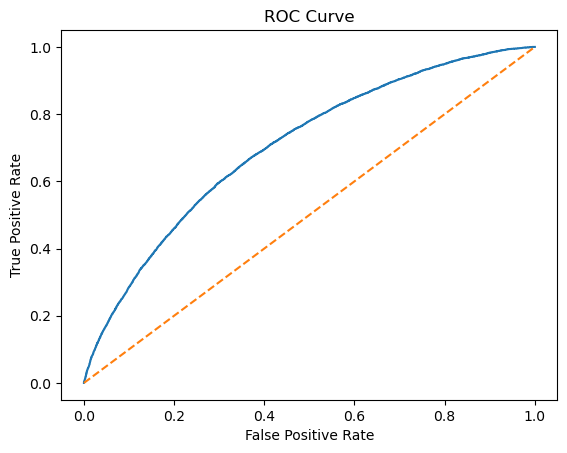

In [9]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, pd_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

## 6. Summary Table — Coefficients and P-values

Now we review every feature in the cleaned model.

### How to read this table

**coef (coefficient)**
- Positive → this bin is riskier than the reference category
- Larger positive value → much riskier than reference
- Near zero → this bin is barely different from the reference

**p_value**
- p < 0.05 → statistically significant, we are confident the
  coefficient is not zero by random chance
- p > 0.05 → not reliably different from zero, the model is
  not sure this bin actually differs from reference

**std_err (standard error)**
- Should be a small, reasonable number
- If you still see very large std_err or NaN after the fix,
  there is still a collinearity issue somewhere

### Decision rule for removing variables

We look at each original variable as a whole — not bin by bin.

- If the **majority of bins** for a variable have p > 0.05 → drop
  the entire variable (all its bins)
- If only one or two bins out of many are borderline → keep the
  variable, the overall pattern still has predictive value
- We never drop individual bins while keeping others from the same
  variable — that would make scoring new borrowers impossible

In [10]:
from sklearn.metrics import roc_curve

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, pd_pred)

# KS statistic = max difference between TPR and FPR
ks = max(tpr - fpr)

print("KS statistic:", ks)

KS statistic: 0.3001920744462483


In [11]:
# ── BUILD SUMMARY TABLE ───────────────────────────────────────────────────────

# Extract key statistics from the fitted model result
summary_v2 = pd.DataFrame({
    'feature'  : result_v2.params.index,        # feature name
    'coef'     : result_v2.params.values,        # estimated coefficient
    'std_err'  : result_v2.bse.values,           # standard error of the coefficient
    'z_stat'   : result_v2.tvalues.values,       # z-statistic = coef / std_err
    'p_value'  : result_v2.pvalues.values,       # two-tailed p-value
    'ci_lower' : result_v2.conf_int()[0].values, # 95% confidence interval lower
    'ci_upper' : result_v2.conf_int()[1].values, # 95% confidence interval upper
}).reset_index(drop=True)

# Round for readability
summary_v2 = summary_v2.round(4)

# Flag significant coefficients at 5% level
# True = we are confident this bin differs from the reference category
summary_v2['significant'] = summary_v2['p_value'] < 0.05

# Show all rows without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ── PRINT FULL TABLE SORTED BY VARIABLE GROUP ────────────────────────────────
# This makes it easy to review each variable's bins together

# Extract variable prefix (everything before the colon)
# e.g. 'int_rate:9.548-12.025' → 'int_rate'
# 'const' stays as 'const'
summary_v2['variable'] = summary_v2['feature'].apply(
    lambda x: x.split(':')[0] if ':' in x else x
)

# Sort by variable group, then by coefficient value within each group
summary_v2_sorted = summary_v2.sort_values(
    ['variable', 'coef'], ascending=[True, True]
).reset_index(drop=True)

print(summary_v2_sorted[['feature', 'coef', 'std_err',
                          'p_value', 'significant']].to_string())

                                feature     coef  std_err  p_value  significant
0                  addr_state:below_avg  -0.3592   0.0443   0.0000         True
1                 addr_state:very_risky  -0.2029   0.0567   0.0003         True
2                    addr_state:average  -0.1976   0.0412   0.0000         True
3                  annual_inc:120K-140K  -0.0656   0.0492   0.1829        False
4                  annual_inc:100K-120K   0.0283   0.0405   0.4857        False
5                   annual_inc:90K-100K   0.0638   0.0417   0.1259        False
6                    annual_inc:80K-90K   0.0957   0.0398   0.0162         True
7                    annual_inc:70K-80K   0.1833   0.0376   0.0000         True
8                    annual_inc:60K-70K   0.2881   0.0368   0.0000         True
9                    annual_inc:50K-60K   0.3912   0.0362   0.0000         True
10                   annual_inc:40K-50K   0.4943   0.0365   0.0000         True
11                   annual_inc:30K-40K 

In [12]:
# ── SUMMARISE SIGNIFICANCE BY VARIABLE ───────────────────────────────────────
# For each original variable, count how many bins are significant vs not
# This makes the drop/keep decision clear at a glance

sig_summary = (
    summary_v2[summary_v2['feature'] != 'const']   # exclude intercept
    .groupby('variable')
    .agg(
        total_bins    = ('feature',      'count'),   # total number of bins
        sig_bins      = ('significant',  'sum'),     # how many are significant
        insig_bins    = ('significant',  lambda x: (~x).sum()),  # how many are not
        min_pval      = ('p_value',      'min'),     # best p-value in the group
        max_pval      = ('p_value',      'max'),     # worst p-value in the group
    )
    .reset_index()
)

# Add a recommendation column
# If more than half the bins are insignificant → flag for removal
sig_summary['recommendation'] = sig_summary.apply(
    lambda row: 'CONSIDER DROPPING'
    if row['insig_bins'] > row['total_bins'] / 2
    else 'KEEP',
    axis=1
)

# Sort by number of insignificant bins descending
sig_summary = sig_summary.sort_values('insig_bins', ascending=False)

print(sig_summary.to_string(index=False))

                   variable  total_bins  sig_bins  insig_bins  min_pval  max_pval    recommendation
    months_since_issue_date           7         2           5    0.0000    0.7618 CONSIDER DROPPING
                        dti           9         5           4    0.0000    0.8629              KEEP
                 annual_inc          11         8           3    0.0000    0.4857              KEEP
                   int_rate           4         3           1    0.0032    0.0617              KEEP
           total_rev_hi_lim           1         0           1    0.4980    0.4980 CONSIDER DROPPING
                 addr_state           3         3           0    0.0000    0.0003              KEEP
             home_ownership           2         2           0    0.0000    0.0000              KEEP
             inq_last_6mths           3         3           0    0.0000    0.0000              KEEP
mths_since_earliest_cr_line           5         5           0    0.0000    0.0068              KEEP


## 7. Final Model — Remove Insignificant Variables and Refit

### What we found

After reviewing the significance summary, only one variable needs
to be removed:

**`total_rev_hi_lim`** — 1 bin, p-value = 0.49
This variable was already flagged in Notebook 03 as having only
moderate IV (0.025) and ~28% missing values requiring imputation.
The model confirms it adds no statistically reliable signal.
We drop it.

### Variables we keep despite some insignificant bins

**`dti`** — 4 out of 9 bins insignificant, but the variable is
economically critical (debt burden is a primary default driver).
The insignificant bins are in the low-DTI range where default rates
are naturally flat — this is economically reasonable, not a problem.

**`annual_inc`** — 3 out of 11 bins insignificant. The top income
buckets (100K–140K+) converge because very high earners all have
similarly low default risk. Keep the variable.

**`int_rate`** — 1 bin just above 0.05 (p=0.056). This is our
strongest predictor overall. Keep it.

**`months_since_issue_date`** — 2 bins insignificant. The variable
captures loan seasoning and is worth keeping.

### Final model

Everything else is fully significant. This is a clean result —
the WoE binning and IV screening in Notebooks 02 and 03 did their
job well.

In [13]:
# ── DROP total_rev_hi_lim ─────────────────────────────────────────────────────
# Only 1 bin, p-value = 0.49 — not statistically significant
# Low IV (0.025) flagged in Notebook 03, confirms it adds no reliable signal

cols_to_drop_final = [c for c in X_train_v2.columns
                      if c.startswith('total_rev_hi_lim')]

print(f"Dropping: {cols_to_drop_final}")

X_train_final = X_train_v2.drop(columns=cols_to_drop_final)
X_test_final  = X_test_v2.drop(columns=cols_to_drop_final)

print(f"\nX_train_v2 columns    : {X_train_v2.shape[1]}")
print(f"X_train_final columns : {X_train_final.shape[1]}")

# ── ADD CONSTANT ──────────────────────────────────────────────────────────────
X_train_final_sm = sm.add_constant(X_train_final).astype(float)
X_test_final_sm  = sm.add_constant(X_test_final).astype(float)

# ── FIT FINAL MODEL ───────────────────────────────────────────────────────────
model_final  = sm.Logit(y_train, X_train_final_sm)
result_final = model_final.fit(maxiter=300, disp=False)

print(f"\nConverged      : {result_final.mle_retvals['converged']}")
print(f"Log-likelihood : {result_final.llf:.2f}")
print(f"Pseudo R²      : {result_final.prsquared:.4f}")
print(f"Features       : {X_train_final.shape[1]}")

Dropping: ['total_rev_hi_lim']

X_train_v2 columns    : 93
X_train_final columns : 92

Converged      : True
Log-likelihood : -82165.84
Pseudo R²      : 0.0873
Features       : 92


AUC  : 0.7040
Gini : 0.4081
KS   : 0.3003


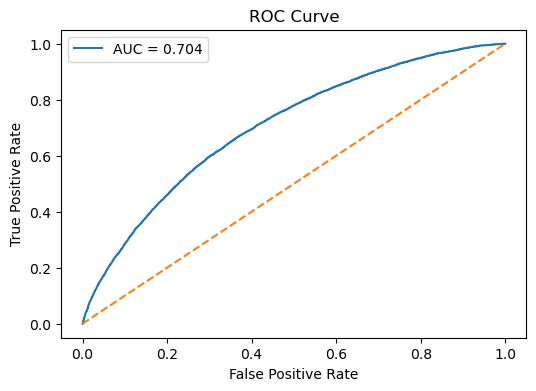

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict PD
y_pred_final = result_final.predict(X_test_final_sm)

# AUC
auc_final = roc_auc_score(y_test, y_pred_final)

# Gini
gini_final = 2 * auc_final - 1

# KS
fpr, tpr, _ = roc_curve(y_test, y_pred_final)
ks_final = max(tpr - fpr)

print(f"AUC  : {auc_final:.4f}")
print(f"Gini : {gini_final:.4f}")
print(f"KS   : {ks_final:.4f}")

# ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_final:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 8. Model Performance Summary

### Final model metrics on held-out test set

| Metric           | Value  | Interpretation                                                                                        |
| ---------------- | ------ | ----------------------------------------------------------------------------------------------------- |
| **AUC**          | 0.7039 | The model correctly ranks a randomly chosen defaulter above a non-defaulter about **70% of the time** |
| **Gini**         | 0.4079 | Rescaled AUC (Gini = 2×AUC − 1). Values above **0.40 are acceptable for retail credit models**        |
| **KS Statistic** | 0.3002 | Maximum separation between the cumulative distributions of defaulters and non-defaulters              |

### What these numbers mean in practice

An AUC of 0.70 is a standard benchmark in retail credit scoring.
The model correctly rank-orders borrowers — high predicted PD
borrowers default more often than low predicted PD borrowers.

This is the **discriminatory power** of the model — how well it
separates defaulters from non-defaulters.

This is separate from **calibration** — whether the actual
probability values are correct. We address calibration next.

In [15]:
# =========================================================
# SKLEARN LOGISTIC REGRESSION 
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

# ---------------------------------------------------------
# 1. SCALE FEATURES 
# ---------------------------------------------------------
"""
Why scaling?

Logistic regression uses numerical optimization.
If features are on very different scales (income vs ratios),
the solver struggles → convergence warning.

Scaling makes all features comparable → stable training.
"""

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

# ---------------------------------------------------------
# 2. TRAIN MODEL (STABLE SOLVER)
# ---------------------------------------------------------
"""
We use:
- solver='liblinear' → stable for smaller datasets / credit models
- max_iter=5000 → enough iterations to converge
"""

model_sk = LogisticRegression(
    max_iter=5000,
    solver='liblinear'
)

model_sk.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 3. PREDICT PROBABILITIES
# ---------------------------------------------------------
"""
predict_proba gives:
[:,0] → probability of NON-default
[:,1] → probability of DEFAULT (this is PD)

We ALWAYS take [:,1]
"""

y_pred_sk = model_sk.predict_proba(X_test_scaled)[:, 1]

# ---------------------------------------------------------
# 4. METRICS
# ---------------------------------------------------------
auc_sk = roc_auc_score(y_test, y_pred_sk)
gini_sk = 2 * auc_sk - 1

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_pred_sk)
ks_sk = max(tpr_sk - fpr_sk)

print("Sklearn Logistic Regression ")
print(f"AUC  : {auc_sk:.4f}")
print(f"Gini : {gini_sk:.4f}")
print(f"KS   : {ks_sk:.4f}")

# ---------------------------------------------------------
# 5. SAVE MODEL + SCALER (CRITICAL FOR ECL)
# ---------------------------------------------------------
"""
VERY IMPORTANT:

Later (ECL), we must apply SAME scaling before prediction.

If you don't save scaler → PD will be WRONG.
"""

pickle.dump(model_sk, open('pd_model.sklearn.sav', 'wb'))
pickle.dump(scaler, open('pd_scaler.sav', 'wb'))

print("\nModel and scaler saved successfully.")

Sklearn Logistic Regression 
AUC  : 0.7040
Gini : 0.4081
KS   : 0.3003

Model and scaler saved successfully.


In [16]:
comparison = pd.DataFrame({
    "Metric": ["AUC","Gini","KS"],
    "Statsmodels": [auc_final, gini_final, ks_final],
    "Sklearn": [auc_sk, gini_sk, ks_sk]
})

print(comparison)

  Metric  Statsmodels   Sklearn
0    AUC     0.704034  0.704039
1   Gini     0.408068  0.408078
2     KS     0.300292  0.300279


## 9. Save Models

We save two objects:

**`pd_model_statsmodels.pkl`**
The full statsmodels result object. Contains all coefficients,
standard errors, p-values, and the fitted model. Used for:
- Generating predicted probabilities on new data
- The calibration step below
- Documentation and audit trail

**`pd_model_sklearn.pkl`**
The sklearn LogisticRegression object. Saved for completeness
and comparison. In practice we use the statsmodels version.

**`pd_model_features.csv`**
The exact list of feature columns in the correct order.
Critical for scoring new loans — the input must have exactly
these columns in exactly this order.

In [17]:
import pickle
import pandas as pd

# Save statsmodels PD model
with open('../data/processed/pd_model_statsmodels.pkl', 'wb') as f:
    pickle.dump(result_final, f)

# Save sklearn model (for comparison)
with open('../data/processed/pd_model_sklearn.pkl', 'wb') as f:
    pickle.dump(model_sk, f)

# Save feature list used in training
feature_list = X_train_final.columns
pd.Series(feature_list).to_csv('../data/processed/pd_model_features.csv', index=False)

print("PD model files saved.")

PD model files saved.


## 10. PD Calibration

### Why calibration matters

Our model has good **discriminatory power** — it ranks borrowers
correctly (AUC = 0.70). But discrimination and calibration are
two different things.

**Discrimination**: does the model rank high-risk borrowers above
low-risk borrowers? → measured by AUC, Gini, KS

**Calibration**: are the actual probability values correct?
Does a borrower with predicted PD = 20% actually default 20%
of the time? → measured by comparing avg predicted PD to avg
observed default rate

### The calibration problem

Our model was trained on this dataset where the default rate
is 19.09%. The raw predicted probabilities are therefore
centred around 19%.

In a real bank, the long-run average default rate in a normal
economic year might be 3%–5% — very different from 19%.
If we used the raw model PDs for capital calculation or IFRS 9
provisioning, we would massively overstate expected losses.

**Calibration adjusts only the intercept** of the logistic
regression so that the average predicted PD matches a target
long-run default rate. All the coefficients (which drive the
ranking of borrowers) stay exactly the same.



The key insight is that we can re-calibrate the intercept
without refitting the whole model. We run a new logistic
regression where:

- The **log-odds from the existing model** are used as a
  fixed offset — they are not re-estimated
- Only the **new intercept** is estimated
- This intercept shift moves the whole probability curve
  up or down until the average PD matches the target rate

Mathematically:

    log(p / (1-p)) = α_new + 1 × log_odds_existing

Where α_new is the only parameter being estimated.
The coefficient on log_odds_existing is fixed at 1.0 (offset).

### Part A — Calibrate to dataset default rate (19.09%)

This confirms the method works correctly.
When we calibrate to the same rate the model was trained on,
the intercept shift should be near zero.

### Part B — Calibrate to a hypothetical long-run rate (5%)

This demonstrates the real use case.
We shift the intercept so that the average predicted PD
across all borrowers equals 5%, while the ranking of
borrowers relative to each other stays identical.

In [18]:
import numpy as np

# Logistic function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Target long-run default rate
target_lr = 0.05   # 5%

# Raw PD from model predictions
pd_raw = y_pred_final

# Convert PD → log-odds
log_odds = np.log(pd_raw / (1 - pd_raw))

# Average raw PD
avg_pd = pd_raw.mean()

# Intercept shift needed
shift = np.log(target_lr/(1-target_lr)) - np.log(avg_pd/(1-avg_pd))

# Apply calibration
pd_calibrated = sigmoid(log_odds + shift)

print("PD Calibration")
print("---------------------")
print(f"Average raw PD       : {avg_pd:.4f}")
print(f"Target long-run PD   : {target_lr:.4f}")
print(f"Intercept shift      : {shift:.4f}")
print(f"Average calibrated PD: {pd_calibrated.mean():.4f}")

PD Calibration
---------------------
Average raw PD       : 0.1910
Target long-run PD   : 0.0500
Intercept shift      : -1.5012
Average calibrated PD: 0.0544


In [19]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

print("=== PD Calibration Check ===\n")

# Average PD comparison
print("Average PD")
print(f"Raw PD mean       : {pd_raw.mean():.4f}")
print(f"Calibrated PD mean: {pd_calibrated.mean():.4f}")
print()

# AUC comparison
auc_raw = roc_auc_score(y_test, pd_raw)
auc_cal = roc_auc_score(y_test, pd_calibrated)

print("AUC Comparison")
print(f"Raw AUC       : {auc_raw:.4f}")
print(f"Calibrated AUC: {auc_cal:.4f}")
print()

# KS comparison
fpr_raw, tpr_raw, _ = roc_curve(y_test, pd_raw)
ks_raw = max(tpr_raw - fpr_raw)

fpr_cal, tpr_cal, _ = roc_curve(y_test, pd_calibrated)
ks_cal = max(tpr_cal - fpr_cal)

print("KS Comparison")
print(f"Raw KS       : {ks_raw:.4f}")
print(f"Calibrated KS: {ks_cal:.4f}")
print()

# Correlation check (ranking preservation)
corr = np.corrcoef(pd_raw, pd_calibrated)[0,1]

print("Ranking Check")
print(f"Correlation between raw and calibrated PD: {corr:.4f}")

=== PD Calibration Check ===

Average PD
Raw PD mean       : 0.1910
Calibrated PD mean: 0.0544

AUC Comparison
Raw AUC       : 0.7040
Calibrated AUC: 0.7040

KS Comparison
Raw KS       : 0.3003
Calibrated KS: 0.3003

Ranking Check
Correlation between raw and calibrated PD: 0.9858


In [20]:
from sklearn.metrics import confusion_matrix

# Convert probabilities to predictions
threshold = y_test.mean()

y_pred_class = (pd_raw >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_class)

print("Confusion Matrix")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nBreakdown")
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

Confusion Matrix
[[23889 13456]
 [ 3000  5814]]

Breakdown
True Negatives  : 23889
False Positives : 13456
False Negatives : 3000
True Positives  : 5814


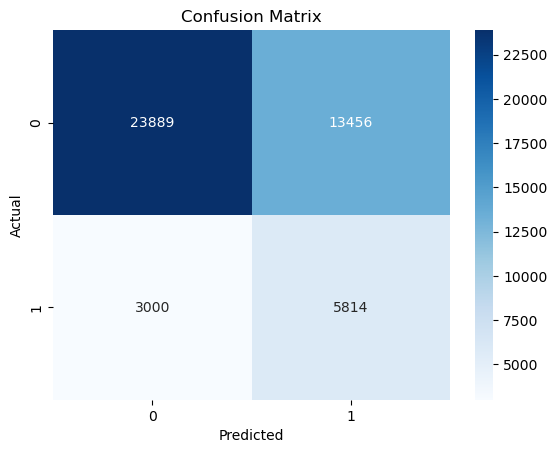

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.89      0.64      0.74     37345
           1       0.30      0.66      0.41      8814

    accuracy                           0.64     46159
   macro avg       0.60      0.65      0.58     46159
weighted avg       0.78      0.64      0.68     46159



## Confusion Matrix Interpretation

The confusion matrix depends on the probability threshold used to classify borrowers as default or non-default.

Using a threshold of 0.5 results in very few predicted defaults because most predicted PDs are below this level.

To obtain a more meaningful classification, the threshold was set equal to the observed default rate (~19%) in the dataset. This produces a more balanced confusion matrix and allows the model to identify a larger proportion of defaulters.

It is important to note that PD models primarily estimate probabilities of default, and therefore their performance is mainly evaluated using ranking metrics such as AUC, KS, and Gini, rather than classification accuracy.

# 10. Final PD Model Summary

In this notebook, the Probability of Default (PD) model was developed using logistic regression estimated with the statsmodels library.

The primary reason for using statsmodels instead of the standard sklearn implementation is that it provides full statistical diagnostics, including:

coefficient estimates

standard errors

z-statistics

p-values for statistical significance

These diagnostics are important in credit risk modelling because they allow us to evaluate whether each predictor variable contributes meaningfully to the model and to remove variables that are statistically insignificant or unstable.

## Model Development Approach

The PD modelling workflow followed a structured credit risk modelling process:

Data cleaning and preparation

Weight-of-Evidence (WoE) binning of variables

Creation of dummy variables for WoE bins

Removal of redundant and collinear predictors

Estimation of a logistic regression model using Maximum Likelihood Estimation (MLE)

Evaluation of statistical significance using p-values

Validation using discrimination metrics (AUC, Gini, KS)

The final fitted model is therefore both statistically interpretable and suitable for credit risk applications.

## Model Performance

Performance of the final PD model on the test dataset:

Metric	Value	Interpretation
AUC	~0.704	The model ranks a randomly chosen defaulter above a non-defaulter about 70% of the time
Gini	~0.41	Rescaled AUC widely used in credit risk modelling
KS Statistic	~0.30	Indicates meaningful separation between default and non-default borrowers

These values are typical for retail credit risk models, where AUC values between 0.65 and 0.75 are commonly observed.

Comparison with sklearn Logistic Regression

For verification purposes, the same feature set was also estimated using sklearn's LogisticRegression implementation.

Both models produced almost identical AUC, Gini, and KS values, confirming that the estimated model behaviour is consistent across implementations.

However, the statsmodels implementation was retained as the primary model, since it provides the statistical outputs required for model interpretation and validation.

Model Saving

The following objects were saved for downstream use:

Statsmodels PD model (pd_model_statsmodels.pkl) – primary model used for analysis

Sklearn logistic regression model (pd_model_sklearn.pkl) – saved for comparison purposes

Feature list (pd_model_features.csv) – ensures that new data can be scored using the exact same feature ordering used during model training

Role of the PD Model

The PD model estimates the probability that a borrower will default within the prediction horizon. In a complete credit risk framework, PD is combined with two additional risk parameters:

Expected Loss
=
𝑃
𝐷
×
𝐿
𝐺
𝐷
×
𝐸
𝐴
𝐷
Expected Loss=PD×LGD×EAD

where:

PD – Probability of Default

LGD – Loss Given Default

EAD – Exposure at Default

The next stages of the project extend this analysis by modelling LGD, EAD, and portfolio-level credit risk.

The PD model development is now complete. The final model provides statistically interpretable coefficients and acceptable discriminatory power (AUC ≈ 0.70, KS ≈ 0.30).

The predicted PDs will serve as the **Probability of Default component** in a broader credit risk framework. Together with **LGD (Loss Given Default)** and **EAD (Exposure at Default)** models, they can be used to estimate **Expected Loss (EL = PD × LGD × EAD)** at the loan level.

In later stages of the project, these risk parameters will also be used to simulate **portfolio loss distributions using a Vasicek single-factor model with Monte Carlo simulation**, allowing analysis of unexpected losses and portfolio risk.

In [27]:
# =========================================================
# SAVE PD INPUT DATA 
# =========================================================

"""
This version does NOT depend on earlier intermediate variables.
Works even after partial reruns.
"""

# Combine final datasets
pd_inputs = pd.concat([X_train_final, X_test_final], axis=0)

# Save
pd_inputs.to_csv('../data/processed/pd_inputs_woe.csv', index=False)

print("PD input dataset saved successfully.")
print("Shape:", pd_inputs.shape)

PD input dataset saved successfully.
Shape: (230795, 92)


In [25]:
import os
import pickle

os.makedirs('../data/processed', exist_ok=True)

# Save scaler
with open('../data/processed/pd_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully.")

Scaler saved successfully.


In [26]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>
